In [1]:
#comparing mean synaptic efficacy and CV Fig1, 2, 5A and FigS2, S3, S16A, S19

import os
import sys
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import scipy.stats as st
import itertools

import itertools
import numpy as np
from datetime import datetime
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from statannot import add_stat_annotation

import seaborn as sns
import pymc as pm
import arviz as az
import scipy.stats as stats

# sns.set(style="whitegrid")
sns.set()
sns.set_style("ticks") 
np.set_printoptions(threshold=1000)

In [2]:
#obtain firing pattern files matching st in sleep firing patterns
def get_dsb(st):

    mp_spikes = os.listdir(savedir + "mp_spikes/sleep/")
    # print(mp_spikes)

    for sp_f in mp_spikes:
    #             print(sp_f)
    
        if sp_f.find(st) !=-1:
            print(sp_f)
            dsb_s = sp_f
            flag =1
            break
    return dsb_s



In [ ]:
#bayse MCMC


def CI_by_bayse(sw, lr_li, Hz_li, out, df_data):
    data_fol = rdir + "/fig_datasets/"+data_name+"/"
          
            
    CI_intervals = []
    
    for m, lr in enumerate(lr_li):
    #     if m>0:
    #         continue

        CI_intervals_Hz = []
        for n, Hz in enumerate(Hz_li):
    #         if n>0:
    #             continue
            if os.path.exists(data_fol + "{}_{}.csv".format(lr,Hz)):
                print("{} already analysed".format(data_fol + "{}_{}.csv".format(lr,Hz)))
                continue
    
            data = df_data[(df_data["lr"]==lr)&(df_data["Hz"]==Hz)]
            s = data[data["state"]=="sleep"][out].tolist()
            w = data[data["state"]=="wake"][out].tolist()
#             print(s)

            plt.hist(w, bins=100)
            plt.hist(s, bins=100)
            plt.show()

            stat_ks, p_value_ks = stats.kstest(s, 'norm', args=(np.mean(s), np.std(s)))
            print("Kolmogorov-Smirnov p-value:", p_value_ks)
            if p_value_ks > 0.05:
                print(lr, Hz, "→ sleep: The data is likely to follow a normal distribution.")
            else:
                print(lr, Hz, "→sleep: The data is not likely to follow a normal distribution.")


            stat_ks, p_value_ks = stats.kstest(w, 'norm', args=(np.mean(w), np.std(w)))
            print("Kolmogorov-Smirnov p-value:", p_value_ks)
            if p_value_ks > 0.05:
                print(lr, Hz, "→ wake: The data is likely to follow a normal distribution.")
            else:
                print(lr, Hz, "→ wake: The data is not likely to follow a normal distribution.")

            with pm.Model() as model:
#                 # 群1のパラメータの事前分布
#                 mu1 = pm.Normal('mu1', mu=np.mean(s), sigma=np.std(s))
#                 sigma1 = pm.HalfNormal('sigma1', sigma=np.std(s))
#                 # 群2のパラメータの事前分布
#                 mu2 = pm.Normal('mu2', mu=np.mean(w), sigma=np.std(w))
#                 sigma2 = pm.HalfNormal('sigma2', sigma=np.std(w))

                # 群1のパラメータの事前分布
                mu1 = pm.Normal('mu1', mu=0, sigma=10)
                sigma1 = pm.HalfNormal('sigma1', sigma=10)
                # 群2のパラメータの事前分布
                mu2 = pm.Normal('mu2', mu=0, sigma=10)
                sigma2 = pm.HalfNormal('sigma2', sigma=10)



                # 観測データの尤度の定義
                obs1 = pm.Normal('obs1', mu=mu1, sigma=sigma1, observed=s)
                obs2 = pm.Normal('obs2', mu=mu2, sigma=sigma2, observed=w)
                # 群間の平均の差を示すパラメータ
                diff = pm.Deterministic('diff', mu1 - mu2)
                # MCMCによるサンプリング
                trace = pm.sample(5000, tune=2000, return_inferencedata=True, random_seed = 42)
            # -------------------------------
            # サンプリング結果の診断と可視化
            # -------------------------------
            # 各パラメータ（mu1, mu2, diff）のトレースプロットの描画
            az.plot_trace(trace, var_names=['mu1', 'mu2', 'diff'])
            plt.show()
            # 要約統計量（平均、信用区間など）の表示（95%信用区間）
            summary = az.summary(trace, var_names=['mu1', 'mu2', 'diff'], hdi_prob=0.95)
            print(summary)
            # -------------------------------
            # 結果の解釈例
            # -------------------------------
            # 有意差の検定は、群間の平均差(diff)の信用区間が0を含むか否かで判断します。
            # 例えば、以下のように解釈できる場合があります。
            # HDI区間を取得
            hdi_array = az.hdi(trace.posterior["diff"], hdi_prob=0.95).to_array().values

            # hdi_array の形状を確認（例: (2, ...)）
            # 数値が１つの場合、squeeze() することでスカラーに変換できます。
            lower_bound = hdi_array[0][0]
            upper_bound = hdi_array[0][1]

            print(lr, Hz, "95% CI  (mu1 - mu2) :", lower_bound, upper_bound)

            if lower_bound > 0:
                print("sleep > wake")
            elif upper_bound < 0:
                print("sleep < wake")
            else:
                print("no_significant")

            CI_intervals_Hz.append([lower_bound, upper_bound])
            print(CI_intervals_Hz)
            
            os.makedirs(data_fol, exist_ok=True)
            np.savetxt(data_fol + "{}_{}.csv".format(lr,Hz), np.array([lower_bound, upper_bound]), delimiter = ",")
        CI_intervals.append(CI_intervals_Hz)
        print(CI_intervals)

    print(CI_intervals)
    return CI_intervals




In [ ]:
# comparing sleep and wake by learning rules
#mean last point, mean syn efficacy
nowdir = os.getcwd()+"/"
savedir = nowdir 

data_name = "Fig 1H"
syn_fol = "synv_by2"
# syn_fol = "synv_by_mf"
NE=10
dsb_w = "ISI_40_0.05_3"#diff5_40_0.05"#
st = "ISIM1.5_durM2.7_45_0.05"  #"diff10_45_0.05" #ISIM2.0_durM2.7_30_0.05"#
lr_p = "a0.7t50"
sw = ["sleep", "wake"]
lr_li =["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
Hz_pre_li = ["0.10","0.30", "1.0", "3.0", "10.0"]#["0.10","0.30", "1.0", "3.0", "10.0"]

Hz_li = []
dsb_s =get_dsb(st)  #"IBI_45_0.05" #
fori_pre = syn_fol+ "/"+dsb_s+"/"+lr_p+"/N_"+str(NE)

for Hz_pre in Hz_pre_li:
    f_pre = savedir + fori_pre + "/STDP_"+ "sleep"+Hz_pre+".csv"
    if os.path.exists(f_pre):
        Hz_li.append(Hz_pre)
        
pairs = []
        
for Hz in Hz_li: 
    pair = ((Hz,"wake"),(Hz,"sleep"))
    pairs.append(pair)
        

print(pairs)

print(Hz_li)
fs = 18
fs_l = 15

colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]

df_data = []
# plt.figure(figsize=(24,15))
for m, lr in enumerate(lr_li):
#     if m!=0:
#         continue
#     plt.subplot(2,2,m+1)
    
    for l,state in enumerate(sw):
        if state == "wake":
            dsb = dsb_w
            
        else:
            dsb = dsb_s
           
        for n, Hz in enumerate(Hz_li):
#     if n>0:
#         continue
            print(Hz+"Hz")
            lastp_Hz = []
            meaneffi_Hz = []
       

#             fori = "synv_" +lr+"_"+method+"_"+state + "/"+dsb+"/"+lr_p+"/N_"+str(NE)
            fori = syn_fol+ "/"+dsb+"/"+lr_p+"/N_"+str(NE)
            f = savedir + fori + "/"+lr+"_"+ state+Hz+".csv"
            print(f)
            syn_v= np.genfromtxt(f, delimiter=",", dtype=np.float64)
            print(lr, state, len(syn_v), np.mean(syn_v,axis = 0))
            #lr_label = np.ones((len(syn_v),1), dtype = "int8")*int(m)
            #syn_v = np.concatenate([syn_v,lr_label], axis = 1)
            #print(syn_v)
    #         lastp_Hz.append(syn_v[:,0])
    #         meaneffi_Hz.append(syn_v[:,1])
            df = pd.DataFrame(syn_v, columns=["order","mean_effi"])
            df["lr"] = lr
            df["state"] = state
            df["Hz"] = Hz
            #print(df)

            if l==0 and n==0:
                dfs = df
            else:
                dfs = pd.concat([dfs, df])
                
            
    df_data.append(dfs)
#     print(dfs)

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "mean_effi"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,
#                                        box_pairs=[(('Hebbian',"wake"),('Anti-Hebbian',"wake")), (('Hebbian',"sleep"),('Anti-Hebbian',"sleep")),
#                                                   (('STDP',"wake"), ('Anti-STDP', "wake")), (('STDP',"sleep"), ('Anti-STDP', "sleep")),
#                                                   (('STDP',"wake"), ('STDP', "sleep")), (('Anti-STDP',"wake"), ('Anti-STDP', "sleep")) ],#lr_coms,
                                       box_pairs= pairs,
#                                               [(('0.10',"wake"),('0.10',"sleep")), (('0.30',"wake"),('0.30',"sleep")),
#                                                   (('1.0',"wake"), ('1.0', "sleep")), (('3.0',"wake"), ('3.0', "sleep")), #(('10.0',"wake"), ('10.0', "sleep"))
#                                                    ],#lr_coms,
# #                                          box_pairs = [(('STDP',"wake"), ('STDP', "sleep"))
#                                                      ],
                                       
                        test='t-test_welch', text_format='star', loc='outside', fontsize=fs, verbose=2)
    #plt.savefig('example_non-hue_outside.png', dpi=300, bbox_inches='tight')
    # colors=['red', 'white']
    # for b, c in zip(ax['boxes'], colors):
    #     b.set(color='red', linewidth=1)  # boxの外枠の色
    #     b.set_facecolor(c) # boxの色
    
    
#     plt.legend([],[], frameon=False)
        
#     plt.subplot(2, 4, n+1)
#     plt.title(Hz+" Hz",fontsize = fs)
#     plt.boxplot(lastp_Hz, labels = lr_li)
#     if n==3:
#         plt.ylim(0., 1)
#     else:
#         plt.ylim(0., 1)
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs)
    ax.set_yticks(np.arange(-0.5,1.3,0.25))
    ax.set_ylim(0., 1.1)

    plt.ylabel("Mean synaptic efficacy", fontsize = fs)
    plt.xlabel("Hz", fontsize = fs)
    ax = plt.gca()
#     ax.axes.xaxis.set_ticklabels([])
#     ax.axes.yaxis.set_ticklabels([])
    
#     ax.spines['right'].set_visible(False)
#     ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
#     plt.tight_layout()
#     plt.savefig("boxplot_{}_random.SVG".format(lr))
#     plt.savefig("boxplot_N{}_{}_{}__mf.SVG".format(NE, lr, lr_p))
    plt.show()
    
df_data = pd.concat(df_data, axis=0)
df_data = df_data.drop('order', axis=1)
data_fol = "/mnt/gpu_data/data8/kinoshita_simulation/fig_datasets/"
# os.makedirs(data_fol, exist_ok=True)
# df_data.to_excel(data_fol + "{}.xlsx".format(data_name))

ISIM1.5_UPM2.7_45_0.05
[(('0.10', 'wake'), ('0.10', 'sleep')), (('0.30', 'wake'), ('0.30', 'sleep')), (('1.0', 'wake'), ('1.0', 'sleep')), (('3.0', 'wake'), ('3.0', 'sleep')), (('10.0', 'wake'), ('10.0', 'sleep'))]
['0.10', '0.30', '1.0', '3.0', '10.0']
0.10Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep0.10.csv
Hebbian sleep 1000 [499.5          0.62615143]
0.30Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep0.30.csv
Hebbian sleep 1000 [499.5          0.67720776]
1.0Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep1.0.csv
Hebbian sleep 1000 [499.5          0.66702324]
3.0Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep3.0.csv
Hebbian sleep 1000 [499.5          0.66910915]
10.0Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep10.0.csv
Hebbian sleep 1000 [499.5          0.68151073]
0.10Hz
../simple_model/synv_by/ISIM_40_0.05/a0.7t50/N_10/Hebbian_wake0

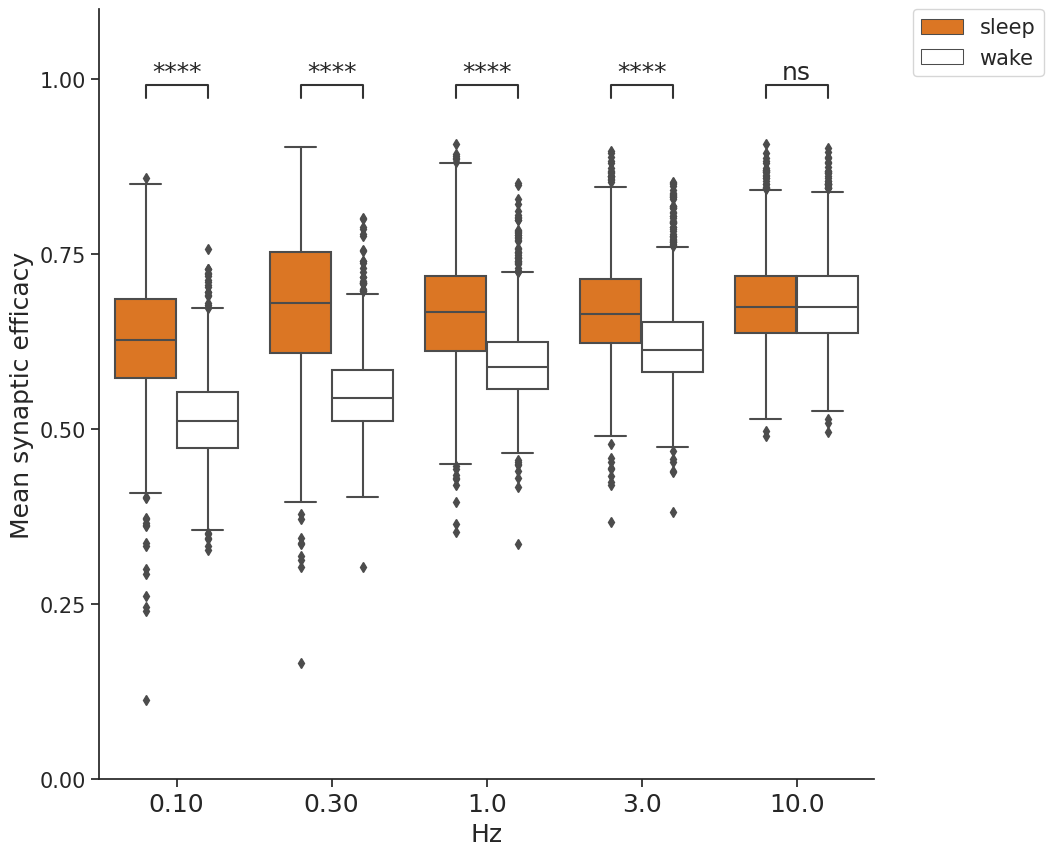

In [11]:
# comparing synaptic efficacy of sleep and wake by learning rules

nowdir = os.getcwd()+"/"
savedir = "../simple_model/"
# sys.path.append(savedir)


data_name = "Fig 1H"
syn_fol = "synv_by"  # "synv_by_random"

NE=10
dsb_w = "ISI_40_0.05_3"#diff5_40_0.05"#
st = "ISIM1.5_durM2.7_45_0.05"  #"diff10_45_0.05" #ISIM2.0_durM2.7_30_0.05"#
lr_p = "a0.7t50"
sw = ["sleep", "wake"]
lr_li =["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
Hz_pre_li = ["0.10","0.30", "1.0", "3.0", "10.0"]#["0.10","0.30", "1.0", "3.0", "10.0"]

Hz_li = []
dsb_s =get_dsb(st)  #"IBI_45_0.05" #
fori_pre = syn_fol+ "/"+dsb_s+"/"+lr_p+"/N_"+str(NE)

for Hz_pre in Hz_pre_li:
    f_pre = savedir + fori_pre + "/STDP_"+ "sleep"+Hz_pre+".csv"
    if os.path.exists(f_pre):
        Hz_li.append(Hz_pre)
        
pairs = []
        
for Hz in Hz_li: 
    pair = ((Hz,"wake"),(Hz,"sleep"))
    pairs.append(pair)
        

print(pairs)

print(Hz_li)
fs = 18
fs_l = 15

colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]

df_data = []
# plt.figure(figsize=(24,15))
for m, lr in enumerate(lr_li):
#     if m!=0:
#         continue
#     plt.subplot(2,2,m+1)
    
    for l,state in enumerate(sw):
        if state == "wake":
            dsb = dsb_w
            
        else:
            dsb = dsb_s
           
        for n, Hz in enumerate(Hz_li):
#     if n>0:
#         continue
            print(Hz+"Hz")
            lastp_Hz = []
            meaneffi_Hz = []
       

#             fori = "synv_" +lr+"_"+method+"_"+state + "/"+dsb+"/"+lr_p+"/N_"+str(NE)
            fori = syn_fol+ "/"+dsb+"/"+lr_p+"/N_"+str(NE)
            f = savedir + fori + "/"+lr+"_"+ state+Hz+".csv"
            print(f)
            syn_v= np.genfromtxt(f, delimiter=",", dtype=np.float64)
            print(lr, state, len(syn_v), np.mean(syn_v,axis = 0))
            #lr_label = np.ones((len(syn_v),1), dtype = "int8")*int(m)
            #syn_v = np.concatenate([syn_v,lr_label], axis = 1)
            #print(syn_v)
    #         lastp_Hz.append(syn_v[:,0])
    #         meaneffi_Hz.append(syn_v[:,1])
            df = pd.DataFrame(syn_v, columns=["order","mean_effi"])
            df["lr"] = lr
            df["state"] = state
            df["Hz"] = Hz
            #print(df)

            if l==0 and n==0:
                dfs = df
            else:
                dfs = pd.concat([dfs, df])
                
            
    df_data.append(dfs)
#     print(dfs)

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "mean_effi"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,
#                                        box_pairs=[(('Hebbian',"wake"),('Anti-Hebbian',"wake")), (('Hebbian',"sleep"),('Anti-Hebbian',"sleep")),
#                                                   (('STDP',"wake"), ('Anti-STDP', "wake")), (('STDP',"sleep"), ('Anti-STDP', "sleep")),
#                                                   (('STDP',"wake"), ('STDP', "sleep")), (('Anti-STDP',"wake"), ('Anti-STDP', "sleep")) ],#lr_coms,
                                       box_pairs= pairs,
#                                               [(('0.10',"wake"),('0.10',"sleep")), (('0.30',"wake"),('0.30',"sleep")),
#                                                   (('1.0',"wake"), ('1.0', "sleep")), (('3.0',"wake"), ('3.0', "sleep")), #(('10.0',"wake"), ('10.0', "sleep"))
#                                                    ],#lr_coms,
# #                                          box_pairs = [(('STDP',"wake"), ('STDP', "sleep"))
#                                                      ],
                                       
                        test='t-test_welch', text_format='star', loc='outside', fontsize=fs, verbose=2)
    #plt.savefig('example_non-hue_outside.png', dpi=300, bbox_inches='tight')
    # colors=['red', 'white']
    # for b, c in zip(ax['boxes'], colors):
    #     b.set(color='red', linewidth=1)  # boxの外枠の色
    #     b.set_facecolor(c) # boxの色
    
    
#     plt.legend([],[], frameon=False)
        
#     plt.subplot(2, 4, n+1)
#     plt.title(Hz+" Hz",fontsize = fs)
#     plt.boxplot(lastp_Hz, labels = lr_li)
#     if n==3:
#         plt.ylim(0., 1)
#     else:
#         plt.ylim(0., 1)
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs)
    ax.set_yticks(np.arange(-0.5,1.3,0.25))
    ax.set_ylim(0., 1.1)

    plt.ylabel("Mean synaptic efficacy", fontsize = fs)
    plt.xlabel("Hz", fontsize = fs)
    ax = plt.gca()
#     ax.axes.xaxis.set_ticklabels([])
#     ax.axes.yaxis.set_ticklabels([])
    
#     ax.spines['right'].set_visible(False)
#     ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
#     plt.tight_layout()
#     plt.savefig("boxplot_{}_random.SVG".format(lr))
#     plt.savefig("boxplot_N{}_{}_{}__mf.SVG".format(NE, lr, lr_p))
    plt.show()
    
df_data = pd.concat(df_data, axis=0)
df_data = df_data.drop('order', axis=1)
data_fol = savedir + "/fig_datasets/"
os.makedirs(data_fol, exist_ok=True)
df_data.to_excel(data_fol + "{}.xlsx".format(data_name))

In [ ]:
#comparing average differences by Bayesian statistics

sw = ["sleep", "wake"]
lr_li =["Hebbian", "STDP","Anti-Hebbian", "Anti-STDP"]
Hz_li = ["0.10","0.30", "1.0", "3.0", "10.0"]
out = "mean_effi"

CI_intervals = CI_by_bayse(sw, lr_li, Hz_li, out, df_data)

ISIM1.5_UPM2.7_45_0.05
[(('0.10', 'wake'), ('0.10', 'sleep')), (('0.30', 'wake'), ('0.30', 'sleep')), (('1.0', 'wake'), ('1.0', 'sleep')), (('3.0', 'wake'), ('3.0', 'sleep')), (('10.0', 'wake'), ('10.0', 'sleep'))]
['0.10', '0.30', '1.0', '3.0', '10.0']
0.10Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep0.10_cv.csv
Hebbian sleep 1000 [4.99500000e+02 3.27845342e-01]
0.30Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep0.30_cv.csv
Hebbian sleep 1000 [4.99500000e+02 2.76630204e-01]
1.0Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep1.0_cv.csv
Hebbian sleep 1000 [4.99500000e+02 2.79603897e-01]
3.0Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep3.0_cv.csv
Hebbian sleep 1000 [4.99500000e+02 2.75876392e-01]
10.0Hz
../simple_model/synv_by/ISIM1.5_UPM2.7_45_0.05/a0.7t50/N_10/Hebbian_sleep10.0_cv.csv
Hebbian sleep 1000 [4.99500000e+02 2.61927885e-01]
0.10Hz
../simple_model/synv_by/ISIM

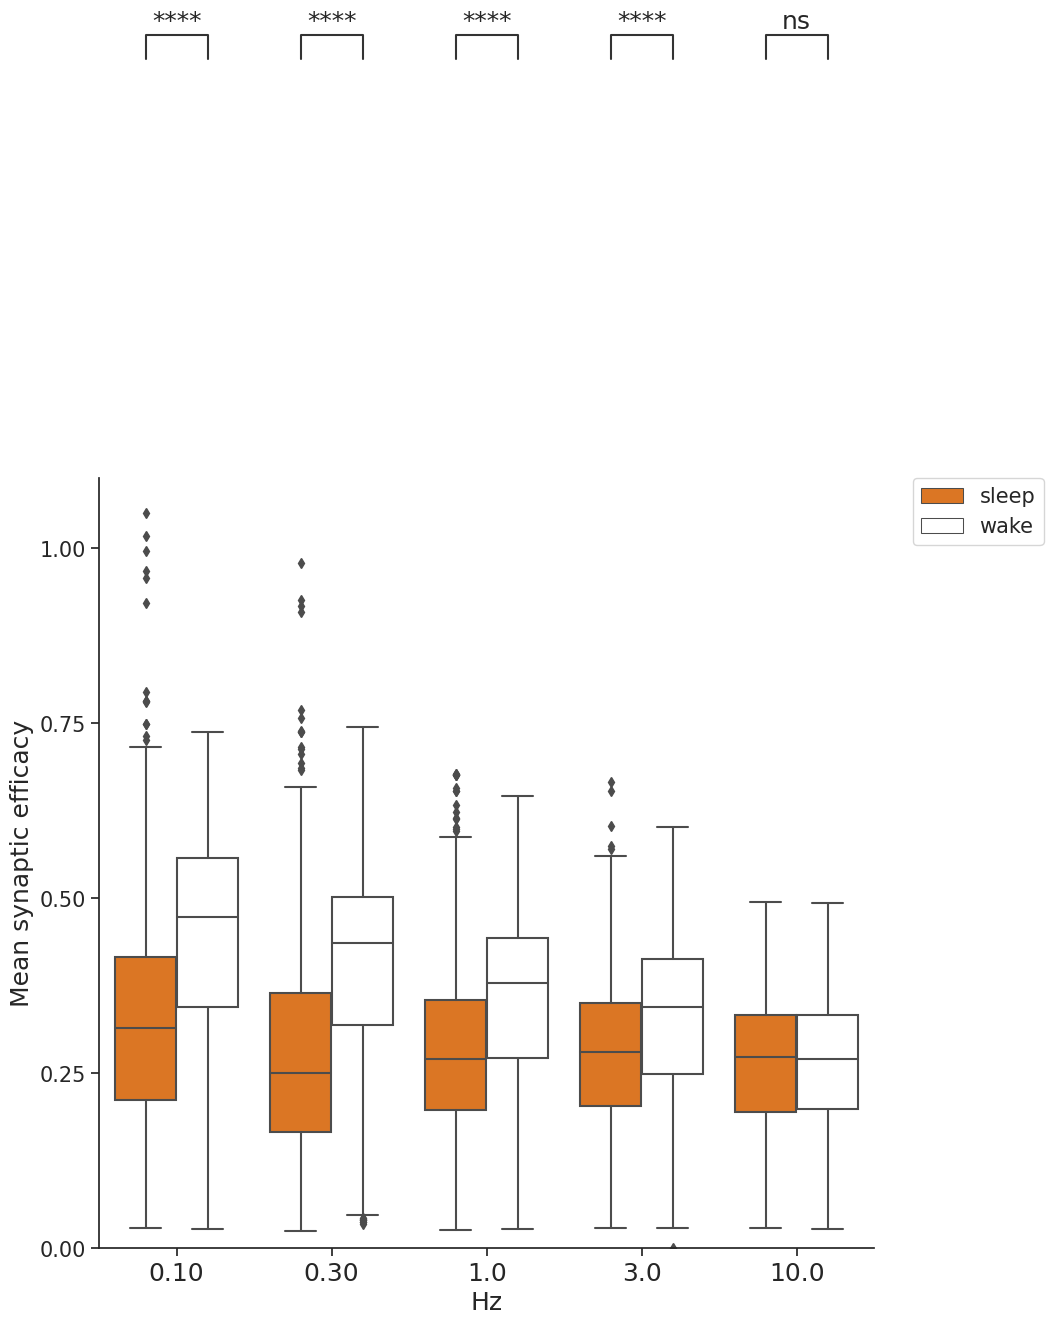

In [12]:
# comparing cv of synaptic efficacy of sleep and wake-like patterns


nowdir = os.getcwd()+"/"
savedir = "../simple_model/"
# sys.path.append(savedir)


syn_fol = "synv_by"

NE=10  #the number of neurons
dsb_w = "ISIM_40_0.05"   #file name of wake-like firing patterns
st = "ISIM1.5_UPM2.7_45_0.05"  #part of #file name of sleep-like firing patterns
lr_p = "a0.7t50"  #parameter for fitting Gausssian curves a:amptitude, t:time constant

dsb_s =get_dsb(st)  #obtain file name of sleep-like firing patterns


sw = ["sleep", "wake"]

lr_li =["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]

Hz_li = []
Hz_pre_li = ["0.10","0.30", "1.0", "3.0", "10.0"]  #firing rate candidate to be compared


for Hz_pre in Hz_pre_li:
    f_pre = savedir +syn_fol+ "/"+dsb_s+"/"+lr_p+"/N_"+str(NE)+ "/Hebbian_"+ "sleep"+Hz_pre+"_cv.csv"
    if os.path.exists(f_pre):
        Hz_li.append(Hz_pre)
        
pairs = []
        
for Hz in Hz_li: 
    pair = ((Hz,"wake"),(Hz,"sleep"))
    pairs.append(pair)
        

print(pairs)

print(Hz_li)
fs = 18
fs_l = 15

colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]



for m, lr in enumerate(lr_li):
    if m>0:
        continue
    
    for l,state in enumerate(sw):
        if state == "wake":
            dsb = dsb_w
            
        else:
            dsb = dsb_s
           
        for n, Hz in enumerate(Hz_li):

            print(Hz+"Hz")
            lastp_Hz = []
            meaneffi_Hz = []
       
            fori = syn_fol+ "/"+dsb+"/"+lr_p+"/N_"+str(NE)
            f = savedir + fori + "/"+lr+"_"+ state+Hz+"_cv.csv"
            print(f)
            syn_v= np.genfromtxt(f, delimiter=",", dtype=np.float64)
            print(lr, state, len(syn_v), np.mean(syn_v,axis = 0))

            df = pd.DataFrame(syn_v, columns=["order","cv"])
            df["lr"] = lr
            df["state"] = state
            df["Hz"] = Hz
            #print(df)

            if l==0 and n==0:
                dfs = df
            else:
                dfs = pd.concat([dfs, df])
#     print(dfs)

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "cv"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,
                                       box_pairs= pairs,
                                      
                        test='t-test_welch', text_format='star', loc='outside', fontsize=fs, verbose=2)
   
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs)
    ax.set_yticks(np.arange(-0.5,1.3,0.25))
    ax.set_ylim(0., 1.1)

    plt.ylabel("Mean synaptic efficacy", fontsize = fs)
    plt.xlabel("Hz", fontsize = fs)
    ax = plt.gca()

    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
#     plt.savefig("boxplot_N{}_{}_{}_cv.SVG".format(NE, lr, lr_p))
    plt.show()

[(('0.10', 'wake'), ('0.10', 'sleep')), (('0.30', 'wake'), ('0.30', 'sleep')), (('1.0', 'wake'), ('1.0', 'sleep')), (('3.0', 'wake'), ('3.0', 'sleep')), (('10.0', 'wake'), ('10.0', 'sleep'))]
['0.10', '0.30', '1.0', '3.0', '10.0']
0.10Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep0.10.csv
Anti-Hebbian sleep 1000 [4.99500000e+02 4.04532582e-01]
0.30Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep0.30.csv
Anti-Hebbian sleep 1000 [4.99500000e+02 3.82633177e-01]
1.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep1.0.csv
Anti-Hebbian sleep 1000 [4.995000e+02 3.797122e-01]
3.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep3.0.csv
Anti-Hebbian sleep 1000 [4.99500000e+02 3.72401934e-01]
10.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep10.0.csv
Anti-Hebbian sleep 1000

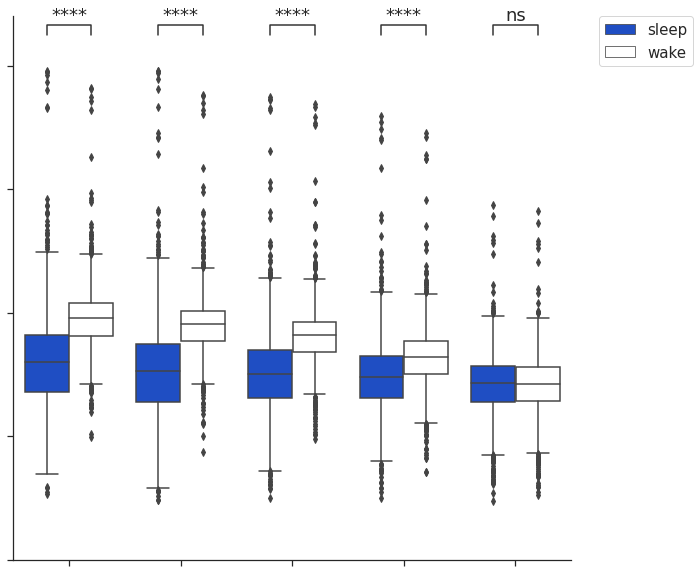

0.10Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep0.10.csv
Anti-STDP sleep 1000 [4.9950000e+02 3.6957341e-01]
0.30Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep0.30.csv
Anti-STDP sleep 1000 [4.99500000e+02 3.69781494e-01]
1.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep1.0.csv
Anti-STDP sleep 1000 [4.99500000e+02 3.53872892e-01]
3.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep3.0.csv
Anti-STDP sleep 1000 [4.99500000e+02 3.54434345e-01]
10.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep10.0.csv
Anti-STDP sleep 1000 [4.99500000e+02 3.49110622e-01]
0.10Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISI_40_0.05_3/a0.7t50/N_10/Anti-STDP_wake0.10.csv
Anti-STDP wake 1000 [499.5          0.52256798]
0.30Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISI_40_0.05_3/a0.7t50/N_10/Anti-STDP_wake0.3

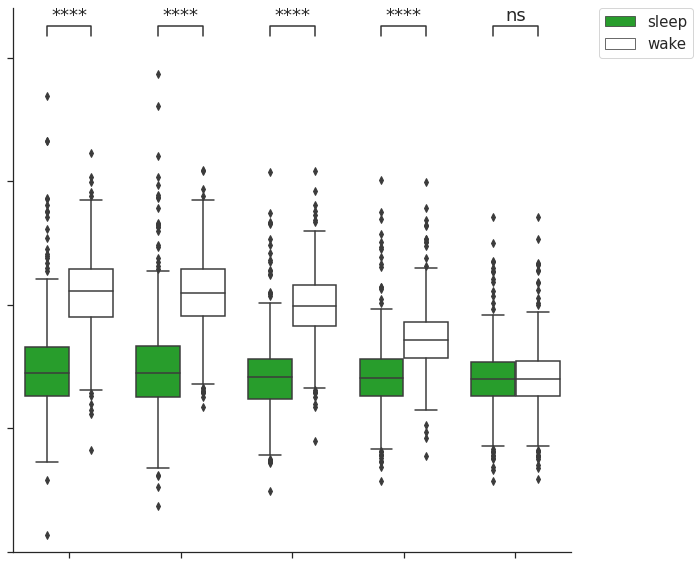

In [5]:
# comparing synaptic efficacy of sleep and wake by learning rules  random connection

nowdir = os.getcwd()+"/"
savedir = "../simple_model/"
# sys.path.append(savedir)


syn_fol = "synv_by_random"

NE=10  #the number of neurons
dsb_w = "ISIM_40_0.05"   #file name of wake-like firing patterns
st = "ISIM1.5_UPM2.7_45_0.05"  #part of #file name of sleep-like firing patterns
lr_p = "a0.7t50"  #parameter for fitting Gausssian curves a:amptitude, t:time constant

dsb_s =get_dsb(st)  #obtain file name of sleep-like firing patterns


sw = ["sleep", "wake"]

lr_li =["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]

Hz_li = []
Hz_pre_li = ["0.10","0.30", "1.0", "3.0", "10.0"] #["20.0", "30.0"]  #firing rate candidate to be compared


for Hz_pre in Hz_pre_li:
    f_pre = savedir +syn_fol+ "/"+dsb_s+"/"+lr_p+"/N_"+str(NE)+ "/Hebbian_"+ "sleep"+Hz_pre+".csv"
    if os.path.exists(f_pre):
        Hz_li.append(Hz_pre)
        
pairs = []
        
for Hz in Hz_li: 
    pair = ((Hz,"wake"),(Hz,"sleep"))
    pairs.append(pair)
        

print(pairs)

print(Hz_li)
fs = 18
fs_l = 15

colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]



for m, lr in enumerate(lr_li):
    if m>0:
        continue
    
    for l,state in enumerate(sw):
        if state == "wake":
            dsb = dsb_w
            
        else:
            dsb = dsb_s
           
        for n, Hz in enumerate(Hz_li):

            print(Hz+"Hz")
            lastp_Hz = []
            meaneffi_Hz = []
       
            fori = syn_fol+ "/"+dsb+"/"+lr_p+"/N_"+str(NE)
            f = savedir + fori + "/"+lr+"_"+ state+Hz+".csv"
            print(f)
            syn_v= np.genfromtxt(f, delimiter=",", dtype=np.float64)
            print(lr, state, len(syn_v), np.mean(syn_v,axis = 0))

            df = pd.DataFrame(syn_v, columns=["order","mean_effi"])
            df["lr"] = lr
            df["state"] = state
            df["Hz"] = Hz
            #print(df)

            if l==0 and n==0:
                dfs = df
            else:
                dfs = pd.concat([dfs, df])
#     print(dfs)

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "mean_effi"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,
                                       box_pairs= pairs,
                                      
                        test='t-test_welch', text_format='star', loc='outside', fontsize=fs, verbose=2)
   
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs)
    ax.set_yticks(np.arange(-0.5,1.3,0.25))
    ax.set_ylim(0., 1.1)

    plt.ylabel("Mean synaptic efficacy", fontsize = fs)
    plt.xlabel("Hz", fontsize = fs)
    ax = plt.gca()

    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
#     plt.savefig("boxplot_N{}_{}_{}_random.SVG".format(NE, lr, lr_p))
    plt.show()

ISIM1.5_durM2.7_45_0.05
[(('0.10', 'wake'), ('0.10', 'sleep')), (('0.30', 'wake'), ('0.30', 'sleep')), (('1.0', 'wake'), ('1.0', 'sleep')), (('3.0', 'wake'), ('3.0', 'sleep')), (('10.0', 'wake'), ('10.0', 'sleep'))]
['0.10', '0.30', '1.0', '3.0', '10.0']
0.10Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep0.10_cv.csv
Anti-Hebbian sleep 1000 [4.99500000e+02 4.56249949e-01]
0.30Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep0.30_cv.csv
Anti-Hebbian sleep 1000 [4.99500000e+02 4.63018009e-01]
1.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep1.0_cv.csv
Anti-Hebbian sleep 1000 [4.99500000e+02 4.58890998e-01]
3.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep3.0_cv.csv
Anti-Hebbian sleep 1000 [499.5   nan]
10.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-Hebbian_sleep10.0_cv.cs

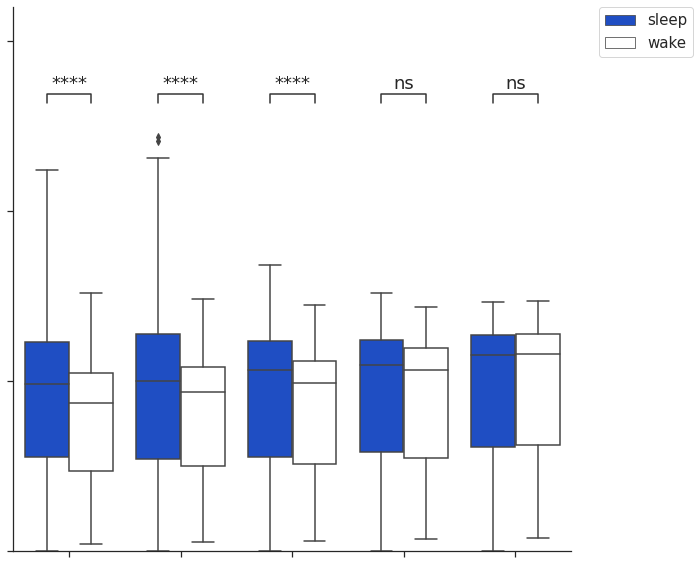

0.10Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep0.10_cv.csv
Anti-STDP sleep 1000 [4.99500000e+02 4.26148441e-01]
0.30Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep0.30_cv.csv
Anti-STDP sleep 1000 [4.99500000e+02 4.15761401e-01]
1.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep1.0_cv.csv
Anti-STDP sleep 1000 [4.99500000e+02 4.14570669e-01]
3.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep3.0_cv.csv
Anti-STDP sleep 1000 [4.99500000e+02 4.11480932e-01]
10.0Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISIM1.5_durM2.7_45_0.05/a0.7t50/N_10/Anti-STDP_sleep10.0_cv.csv
Anti-STDP sleep 1000 [4.99500000e+02 4.14875513e-01]
0.10Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISI_40_0.05_3/a0.7t50/N_10/Anti-STDP_wake0.10_cv.csv
Anti-STDP wake 1000 [4.99500000e+02 3.31616095e-01]
0.30Hz
/mnt/SSD1/lr_params/synv_seed_0.88/ISI_40_0.05_3/a0.7t5

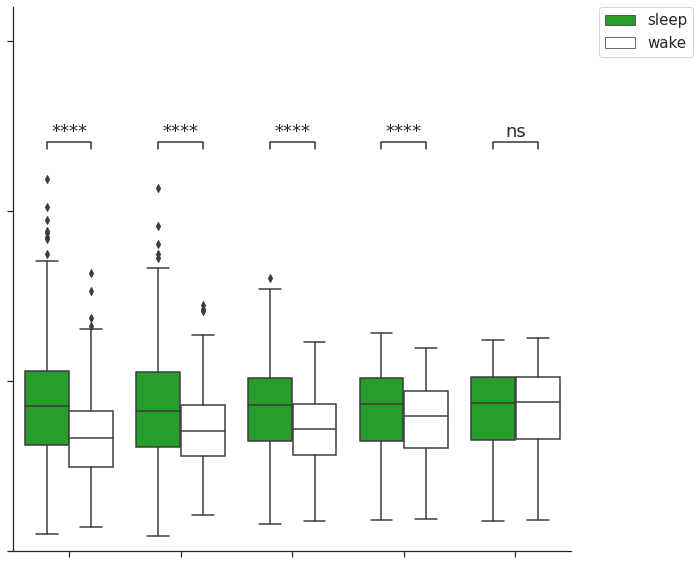

In [6]:
# comparing cv of synaptic efficacy of sleep and wake-like patterns  random connection


nowdir = os.getcwd()+"/"
savedir = "../simple_model/"


syn_fol = "synv_by_random"

NE=10  #the number of neurons
dsb_w = "ISIM_40_0.05"   #file name of wake-like firing patterns
st = "ISIM1.5_UPM2.7_45_0.05"  #part of #file name of sleep-like firing patterns
lr_p = "a0.7t50"  #parameter for fitting Gausssian curves a:amptitude, t:time constant

dsb_s =get_dsb(st)  #obtain file name of sleep-like firing patterns


sw = ["sleep", "wake"]

lr_li =["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]

Hz_li = []
Hz_pre_li = ["0.10","0.30", "1.0", "3.0", "10.0"]  #firing rate candidate to be compared


for Hz_pre in Hz_pre_li:
    f_pre = savedir +syn_fol+ "/"+dsb_s+"/"+lr_p+"/N_"+str(NE)+ "/Hebbian_"+ "sleep"+Hz_pre+"_cv.csv"
    if os.path.exists(f_pre):
        Hz_li.append(Hz_pre)
        
pairs = []
        
for Hz in Hz_li: 
    pair = ((Hz,"wake"),(Hz,"sleep"))
    pairs.append(pair)
        

print(pairs)

print(Hz_li)
fs = 18
fs_l = 15

colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]



for m, lr in enumerate(lr_li):
    if m>0:
        continue
    
    for l,state in enumerate(sw):
        if state == "wake":
            dsb = dsb_w
            
        else:
            dsb = dsb_s
           
        for n, Hz in enumerate(Hz_li):

            print(Hz+"Hz")
            lastp_Hz = []
            meaneffi_Hz = []
       
            fori = syn_fol+ "/"+dsb+"/"+lr_p+"/N_"+str(NE)
            f = savedir + fori + "/"+lr+"_"+ state+Hz+"_cv.csv"
            print(f)
            syn_v= np.genfromtxt(f, delimiter=",", dtype=np.float64)
            print(lr, state, len(syn_v), np.mean(syn_v,axis = 0))

            df = pd.DataFrame(syn_v, columns=["order","cv"])
            df["lr"] = lr
            df["state"] = state
            df["Hz"] = Hz
            #print(df)

            if l==0 and n==0:
                dfs = df
            else:
                dfs = pd.concat([dfs, df])
#     print(dfs)

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "cv"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,
                                       box_pairs= pairs,
                                      
                        test='t-test_welch', text_format='star', loc='outside', fontsize=fs, verbose=2)
   
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs)
    ax.set_yticks(np.arange(-0.5,1.3,0.25))
    ax.set_ylim(0., 1.1)

    plt.ylabel("Mean synaptic efficacy", fontsize = fs)
    plt.xlabel("Hz", fontsize = fs)
    ax = plt.gca()

    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
#     plt.savefig("boxplot_N{}_{}_{}_random_cv.SVG".format(NE, lr, lr_p))
    plt.show()

In [ ]:
# comparing synaptic efficacy of sleep and wake by learning rules, Fig 5

nowdir = os.getcwd()+"/"
savedir = "../simple_model/"
# sys.path.append(savedir)


syn_fol = "synv_by_mf"  # "synv_by_random"

NE=10  #the number of neurons
dsb_w = "ISIM_40_0.05"   #file name of wake-like firing patterns
st = "DOWNM3.0_UPM2.7_157_0.05"  #part of #file name of sleep-like firing patterns
lr_p = "a0.7t50"  #parameter for fitting Gausssian curves a:amptitude, t:time constant

dsb_s =get_dsb(st)  #obtain file name of sleep-like firing patterns


sw = ["sleep", "wake"]

lr_li =["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]

Hz_li = []
Hz_pre_li = ["0.01", "0.03", "0.10","0.30", "1.0", "3.0", "10.0"] #["20.0", "30.0"]  #firing rate candidate to be compared


for Hz_pre in Hz_pre_li:
    f_pre = savedir +syn_fol+ "/"+dsb_s+"/"+lr_p+"/N_"+str(NE)+ "/Hebbian_"+ "sleep"+Hz_pre+".csv"
    if os.path.exists(f_pre):
        Hz_li.append(Hz_pre)
        
pairs = []
        
for Hz in Hz_li: 
    pair = ((Hz,"wake"),(Hz,"sleep"))
    pairs.append(pair)
        

print(pairs)

print(Hz_li)
fs = 18
fs_l = 15

colors =[sns.xkcd_rgb["orange"], sns.xkcd_rgb["blue"], sns.xkcd_rgb["magenta"], sns.xkcd_rgb["green"]]



for m, lr in enumerate(lr_li):
    if m>0:
        continue
    
    for l,state in enumerate(sw):
        if state == "wake":
            dsb = dsb_w
            
        else:
            dsb = dsb_s
           
        for n, Hz in enumerate(Hz_li):

            print(Hz+"Hz")
            lastp_Hz = []
            meaneffi_Hz = []
       
            fori = syn_fol+ "/"+dsb+"/"+lr_p+"/N_"+str(NE)
            f = savedir + fori + "/"+lr+"_"+ state+Hz+".csv"
            print(f)
            syn_v= np.genfromtxt(f, delimiter=",", dtype=np.float64)
            print(lr, state, len(syn_v), np.mean(syn_v,axis = 0))

            df = pd.DataFrame(syn_v, columns=["order","mean_effi"])
            df["lr"] = lr
            df["state"] = state
            df["Hz"] = Hz
            #print(df)

            if l==0 and n==0:
                dfs = df
            else:
                dfs = pd.concat([dfs, df])
#     print(dfs)

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "mean_effi"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,
                                       box_pairs= pairs,
                                      
                        test='t-test_welch', text_format='star', loc='outside', fontsize=fs, verbose=2)
   
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs)
    ax.set_yticks(np.arange(-0.5,1.3,0.25))
    ax.set_ylim(0., 1.1)

    plt.ylabel("Mean synaptic efficacy", fontsize = fs)
    plt.xlabel("Hz", fontsize = fs)
    ax = plt.gca()

    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
#     plt.savefig("boxplot_N{}_{}_{}_mf.SVG".format(NE, lr, lr_p))
    plt.show()

IBIM2.4_durM2.1
IBIM2.4_durM2.1_750_0.05
0.040486999999999995
IBIM2.4_durM2.4
IBIM2.4_durM2.4_515_0.05
0.030388499999999985
IBIM2.4_durM2.7
IBIM2.4_durM2.7_26_0.05
0.04785500000000009
IBIM2.4_durM3.0
IBIM2.4_durM3.0_810_0.05
0.03604249999999998
IBIM2.7_durM2.1
IBIM2.7_durM2.1_624_0.05
0.04487300000000005
IBIM2.7_durM2.4
IBIM2.7_durM2.4_193_0.05
0.054624000000000006
IBIM2.7_durM2.7
IBIM2.7_durM2.7_642_0.05
0.04015599999999997
IBIM2.7_durM3.0
IBIM2.7_durM3.0_426_0.05
0.046645999999999965
IBIM3.0_durM2.1
IBIM3.0_durM2.1_686_0.05
0.04071349999999996
IBIM3.0_durM2.4
IBIM3.0_durM2.4_329_0.05
0.04829249999999996
IBIM3.0_durM2.7
IBIM3.0_durM2.7_636_0.05
0.053218499999999946
IBIM3.0_durM3.0
IBIM3.0_durM3.0_406_0.05
0.05365949999999997
IBIM3.3_durM2.1
IBIM3.3_durM2.1_529_0.05
0.07023299999999999
IBIM3.3_durM2.4
IBIM3.3_durM2.4_51_0.05
0.058985500000000024
IBIM3.3_durM2.7
IBIM3.3_durM2.7_572_0.05
0.06245999999999996
IBIM3.3_durM3.0
IBIM3.3_durM3.0_68_0.05
0.054857500000000003


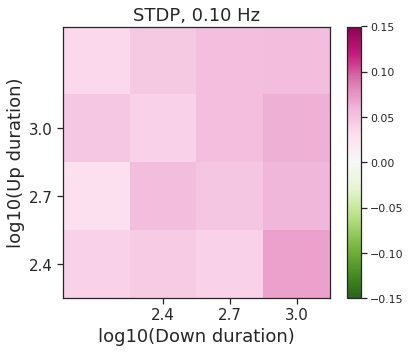

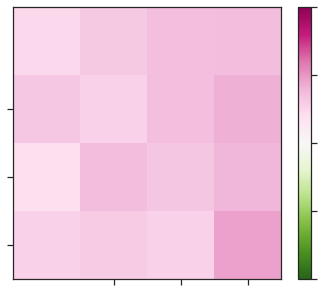

IBIM2.4_durM2.1
IBIM2.4_durM2.1_750_0.05
-0.01198750000000004
IBIM2.4_durM2.4
IBIM2.4_durM2.4_515_0.05
0.0008444999999999703
IBIM2.4_durM2.7
IBIM2.4_durM2.7_26_0.05
0.006266499999999953
IBIM2.4_durM3.0
IBIM2.4_durM3.0_810_0.05
0.014626499999999987
IBIM2.7_durM2.1
IBIM2.7_durM2.1_624_0.05
0.011456000000000022
IBIM2.7_durM2.4
IBIM2.7_durM2.4_193_0.05
0.00607949999999996
IBIM2.7_durM2.7
IBIM2.7_durM2.7_642_0.05
0.019909500000000024
IBIM2.7_durM3.0
IBIM2.7_durM3.0_426_0.05
0.02976599999999996
IBIM3.0_durM2.1
IBIM3.0_durM2.1_686_0.05
0.03421200000000002
IBIM3.0_durM2.4
IBIM3.0_durM2.4_329_0.05
0.007559499999999941
IBIM3.0_durM2.7
IBIM3.0_durM2.7_636_0.05
0.01771899999999993
IBIM3.0_durM3.0
IBIM3.0_durM3.0_406_0.05
0.020133499999999915
IBIM3.3_durM2.1
IBIM3.3_durM2.1_529_0.05
0.09743999999999997
IBIM3.3_durM2.4
IBIM3.3_durM2.4_51_0.05
0.0490259999999999
IBIM3.3_durM2.7
IBIM3.3_durM2.7_572_0.05
0.029423499999999936
IBIM3.3_durM3.0
IBIM3.3_durM3.0_68_0.05
0.013589999999999991


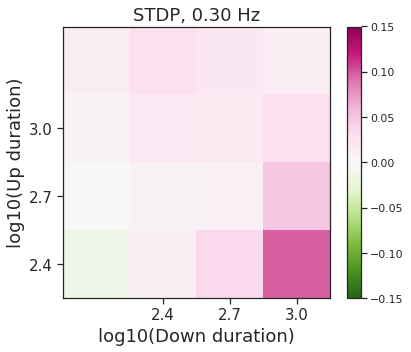

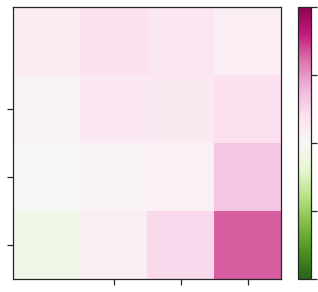

IBIM2.4_durM2.1
IBIM2.4_durM2.1_750_0.05
-0.031237999999999988
IBIM2.4_durM2.4
IBIM2.4_durM2.4_515_0.05
-0.042901999999999996
IBIM2.4_durM2.7
IBIM2.4_durM2.7_26_0.05
-0.043200500000000086
IBIM2.4_durM3.0
IBIM2.4_durM3.0_810_0.05
-0.04855149999999997
IBIM2.7_durM2.1
IBIM2.7_durM2.1_624_0.05
0.01410750000000005
IBIM2.7_durM2.4
IBIM2.7_durM2.4_193_0.05
-0.016106000000000065
IBIM2.7_durM2.7
IBIM2.7_durM2.7_642_0.05
-0.032472000000000056
IBIM2.7_durM3.0
IBIM2.7_durM3.0_426_0.05
-0.03218700000000008
IBIM3.0_durM2.1
IBIM3.0_durM2.1_686_0.05
0.08335499999999996
IBIM3.0_durM2.4
IBIM3.0_durM2.4_329_0.05
0.0339005
IBIM3.0_durM2.7
IBIM3.0_durM2.7_636_0.05
-0.0010059999999999514
IBIM3.0_durM3.0
IBIM3.0_durM3.0_406_0.05
-0.02064150000000009
IBIM3.3_durM2.1
IBIM3.3_durM2.1_529_0.05
0.14283650000000003
IBIM3.3_durM2.4
IBIM3.3_durM2.4_51_0.05
0.09000299999999994
IBIM3.3_durM2.7
IBIM3.3_durM2.7_572_0.05
0.09517299999999995
IBIM3.3_durM3.0
IBIM3.3_durM3.0_68_0.05
0.0020455000000000334


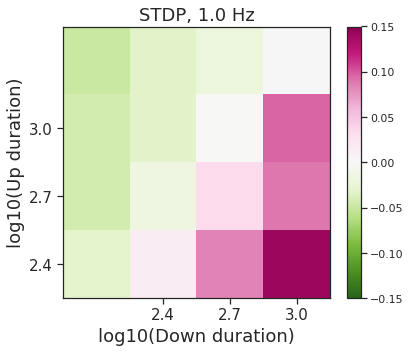

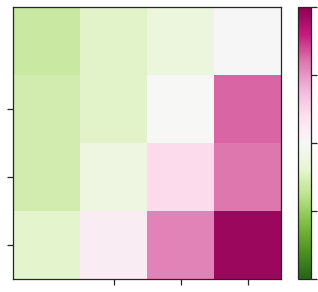

IBIM2.4_durM2.1
IBIM2.4_durM2.1_750_0.05
0.029041500000000053
IBIM2.4_durM2.4
IBIM2.4_durM2.4_515_0.05
0.004947000000000035
IBIM2.4_durM2.7
IBIM2.4_durM2.7_26_0.05
-0.024183500000000024
IBIM2.4_durM3.0
IBIM2.4_durM3.0_810_0.05
-0.03281299999999998
IBIM2.7_durM2.1
IBIM2.7_durM2.1_624_0.05
0.07985549999999997
IBIM2.7_durM2.4
IBIM2.7_durM2.4_193_0.05
0.055552999999999964
IBIM2.7_durM2.7
IBIM2.7_durM2.7_642_0.05
0.017001000000000044
IBIM2.7_durM3.0
IBIM2.7_durM3.0_426_0.05
-0.016528500000000057
IBIM3.0_durM2.1
IBIM3.0_durM2.1_686_0.05
0.12206949999999994
IBIM3.0_durM2.4
IBIM3.0_durM2.4_329_0.05
0.10327949999999997
IBIM3.0_durM2.7
IBIM3.0_durM2.7_636_0.05
0.06897500000000001
IBIM3.0_durM3.0
IBIM3.0_durM3.0_406_0.05
0.02844800000000003
IBIM3.3_durM2.1
IBIM3.3_durM2.1_529_0.05
0.137722
IBIM3.3_durM2.4
IBIM3.3_durM2.4_51_0.05
0.128853
IBIM3.3_durM2.7
IBIM3.3_durM2.7_572_0.05
0.12453400000000003
IBIM3.3_durM3.0
IBIM3.3_durM3.0_68_0.05
0.08316049999999997


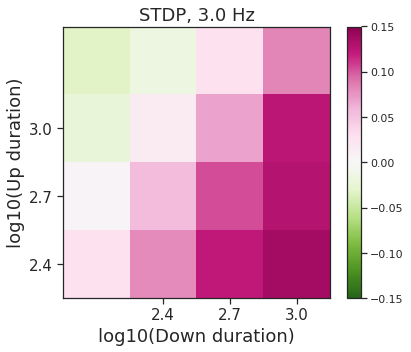

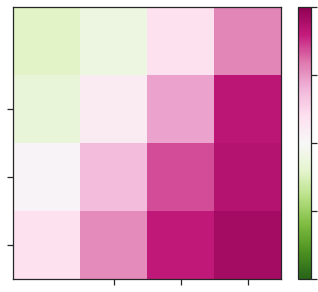

IBIM2.4_durM2.1
IBIM2.4_durM2.1_750_0.05
0.02834800000000004
IBIM2.4_durM2.4
IBIM2.4_durM2.4_515_0.05
0.026096000000000008
IBIM2.4_durM2.7
IBIM2.4_durM2.7_26_0.05
0.01484350000000001
IBIM2.4_durM3.0
IBIM2.4_durM3.0_810_0.05
0.005916000000000032
IBIM2.7_durM2.1
IBIM2.7_durM2.1_624_0.05
0.05673400000000006
IBIM2.7_durM2.4
IBIM2.7_durM2.4_193_0.05
0.04406399999999999
IBIM2.7_durM2.7
IBIM2.7_durM2.7_642_0.05
0.026251000000000024
IBIM2.7_durM3.0
IBIM2.7_durM3.0_426_0.05
0.019062000000000023
IBIM3.0_durM2.1
IBIM3.0_durM2.1_686_0.05
0.06532749999999998
IBIM3.0_durM2.4
IBIM3.0_durM2.4_329_0.05
0.06151850000000003
IBIM3.0_durM2.7
IBIM3.0_durM2.7_636_0.05
0.05426299999999995
IBIM3.0_durM3.0
IBIM3.0_durM3.0_406_0.05
0.04007000000000005
IBIM3.3_durM2.1
IBIM3.3_durM2.1_529_0.05
0
IBIM3.3_durM2.4
IBIM3.3_durM2.4_51_0.05
0.06790399999999996
IBIM3.3_durM2.7
IBIM3.3_durM2.7_572_0.05
0.07019500000000001
IBIM3.3_durM3.0
IBIM3.3_durM3.0_68_0.05
0.05673949999999994


Traceback (most recent call last):
  File "/tmp/ipykernel_1463192/89808168.py", line 68, in <cell line: 45>
    syn_v_s= np.genfromtxt(f_s, delimiter=",", dtype=np.float64)
  File "/home/user/.local/lib/python3.8/site-packages/numpy/lib/npyio.py", line 1813, in genfromtxt
    fid = np.lib._datasource.open(fname, 'rt', encoding=encoding)
  File "/home/user/.local/lib/python3.8/site-packages/numpy/lib/_datasource.py", line 193, in open
    return ds.open(path, mode, encoding=encoding, newline=newline)
  File "/home/user/.local/lib/python3.8/site-packages/numpy/lib/_datasource.py", line 532, in open
    raise FileNotFoundError(f"{path} not found.")
FileNotFoundError: /mnt/SSD1/lr_params/synv_by3/IBIM3.3_durM2.1_529_0.05/a0.7t50/N_10/STDP_sleep10.0.csv not found.


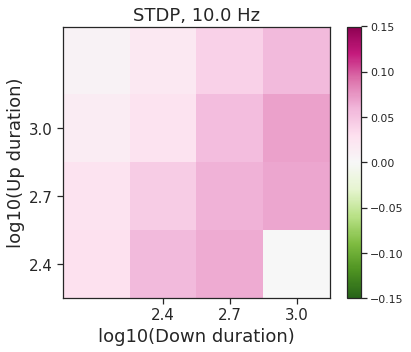

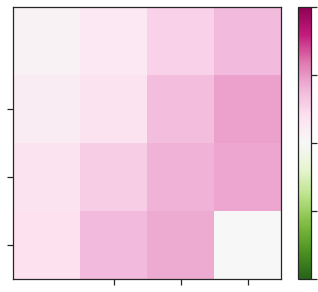

In [4]:
#comparing mean synaptic effi by learning rules and Hz by colormap  chaging ISIM  Fig 2
from mpl_toolkits.mplot3d import Axes3D   
import matplotlib.pyplot as plt 
from matplotlib.colors import Normalize
import traceback
import matplotlib as mpl

nowdir = os.getcwd()+"/"
savedir = "../simple_model/"

syn_fol = "synv_by"
lr_p = "a0.7t50"
method = "median"  #mean
norm =True
vmin = -0.15       
vmax = 0.15



sw = ["sleep", "wake"]
x_label=["2.4","2.7", "3.0", "3.3"]
y_label=["2.1", "2.4","2.7", "3.0"]
lr_li = ["STDP"]#["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
Hz_li = ["0.10", "0.30", "1.0", "3.0", "10.0"]

fs = 18
fs_l = 15

NE=10
dsb_w = "ISIM_40_0.05"
sleep_x = "DOWNM"
sleep_y = "UPM"
x_li = [2.4, 2.7,3.0,  3.3] #IBI_M or ISIM
y_li =[2.1, 2.4, 2.7, 3.0]  #durM

x, y = np.meshgrid(np.array(x_li), np.array(y_li))
z = np.zeros((len(y_li),len(x_li)))

files = os.listdir(savedir + syn_fol +"/")

for lr in lr_li:
    for Hz in Hz_li:

        for m, ix in enumerate(x_li):
            for n,iy in enumerate(y_li):
                st = sleep_x+ str(ix) +"_" + sleep_y+ str(iy) 
                print(st)
                flag = 0
                for sp_f in files:
        #             print(sp_f)
                    if sp_f.find(st) !=-1:
                        print(sp_f)
                        dsb_s = sp_f
                        flag =1
                        break

                if flag ==0:
                    print("{} not found".format(st))

                else:
                    try:
                        fori_s = syn_fol+ "/"+dsb_s+"/"+lr_p+"/N_"+str(NE)
                        f_s = savedir + fori_s + "/"+lr+"_"+ "sleep"+Hz+".csv"
                        syn_v_s= np.genfromtxt(f_s, delimiter=",", dtype=np.float64)
        #                             s_m_li.append(np.mean(syn_v_s, axis=0)[1])
                        fori_w = syn_fol+ "/"+dsb_w+"/"+lr_p+"/N_"+str(NE)
                        f_w = savedir + fori_w + "/"+lr+"_"+ "wake"+Hz+".csv"
                        syn_v_w= np.genfromtxt(f_w, delimiter=",", dtype=np.float64)
        #                             w_m_li.append(np.mean(syn_v_w, axis=0)[1])
                        if method =="mean":
                            diff = np.mean(syn_v_s, axis=0)[1] - np.mean(syn_v_w, axis=0)[1]
                        elif method =="median":
                            diff = np.median(syn_v_s, axis=0)[1] - np.median(syn_v_w, axis=0)[1]
                    except:
                        traceback.print_exc()
                        diff = 0
                    z[m][n] = diff
                    print(diff)

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.set_title("{}, {} Hz".format(lr, Hz),fontsize = fs )
#         ax.set_xticks(x_li)
#         ax.set_yticks(y_li)
#         ax.tick_params("x", labelsize = fs_l)
#         ax.tick_params("y", labelsize = fs_l)
#         ax.set_xlabel("log10(Down duration)", fontsize = fs)
#         ax.set_ylabel("log10(Up duration)", fontsize = fs)
        #                         
        if norm ==True:
            mappable=ax.pcolormesh(y,x,z, cmap="PiYG_r", norm=Normalize(vmin=vmin, vmax=vmax))
        else:
            mappable=ax.pcolormesh(y,x,z, cmap="PiYG_r")
        fig.colorbar(mappable, ax=ax)
        
        ax = plt.gca()
        ax.axes.xaxis.set_ticklabels([])
        ax.axes.yaxis.set_ticklabels([])

        plt.savefig("STDP_down_up_{}.SVG".format(Hz))
        plt.show()                   



ISIM1.0_durM2.1
ISIM1.0_durM2.1_396_0.05
0.2576299999999999
ISIM1.0_durM2.4
ISIM1.0_durM2.4_487_0.05
0.2371605
ISIM1.0_durM2.7
ISIM1.0_durM2.7_960_0.05
0.22608400000000006
ISIM1.0_durM3.0
ISIM1.0_durM3.0_855_0.05
0.23641250000000003
ISIM1.5_durM2.1
ISIM1.5_durM2.1_132_0.05
0.1991885
ISIM1.5_durM2.4
ISIM1.5_durM2.4_181_0.05
0.20749849999999992
ISIM1.5_durM2.7
ISIM1.5_durM2.7_45_0.05
0.17472500000000002
ISIM1.5_durM3.0
ISIM1.5_durM3.0_616_0.05
0.20494749999999995
ISIM2.0_durM2.1
ISIM2.0_durM2.1_296_0.05
0.09333249999999993
ISIM2.0_durM2.4
ISIM2.0_durM2.4_446_0.05
0.11525549999999996
ISIM2.0_durM2.7
ISIM2.0_durM2.7_407_0.05
0.13396850000000005
ISIM2.0_durM3.0
ISIM2.0_durM3.0_741_0.05
0.06007050000000003
ISIM2.5_durM2.1
ISIM2.5_durM2.1_949_0.05
0.07955750000000006
ISIM2.5_durM2.4
ISIM2.5_durM2.4_654_0.05
0.06964150000000002
ISIM2.5_durM2.7
ISIM2.5_durM2.7_142_0.05
0.08821800000000002
ISIM2.5_durM3.0
ISIM2.5_durM3.0_687_0.05
0.10589499999999996


/tmp/ipykernel_2254423/1389764609.py:85: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_label)


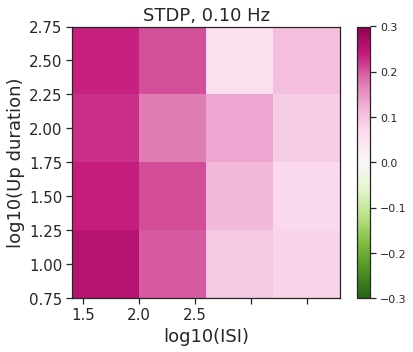

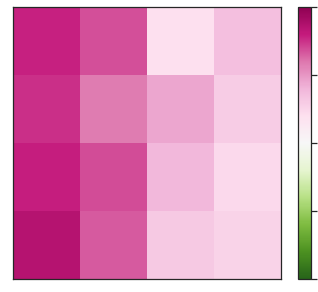

ISIM1.0_durM2.1
ISIM1.0_durM2.1_396_0.05
0.21188099999999999
ISIM1.0_durM2.4
ISIM1.0_durM2.4_487_0.05
0.21755399999999991
ISIM1.0_durM2.7
ISIM1.0_durM2.7_960_0.05
0.221727
ISIM1.0_durM3.0
ISIM1.0_durM3.0_855_0.05
0.23255400000000004
ISIM1.5_durM2.1
ISIM1.5_durM2.1_132_0.05
0.1619505
ISIM1.5_durM2.4
ISIM1.5_durM2.4_181_0.05
0.17842449999999987
ISIM1.5_durM2.7
ISIM1.5_durM2.7_45_0.05
0.18882900000000002
ISIM1.5_durM3.0
ISIM1.5_durM3.0_616_0.05
0.19706999999999997
ISIM2.0_durM2.1
ISIM2.0_durM2.1_296_0.05
0.09609699999999999
ISIM2.0_durM2.4
ISIM2.0_durM2.4_446_0.05
0.10247050000000002
ISIM2.0_durM2.7
ISIM2.0_durM2.7_407_0.05
0.09305700000000006
ISIM2.0_durM3.0
ISIM2.0_durM3.0_741_0.05
0.09957899999999997
ISIM2.5_durM2.1
ISIM2.5_durM2.1_949_0.05
0.04270099999999999
ISIM2.5_durM2.4
ISIM2.5_durM2.4_654_0.05
0.0539115
ISIM2.5_durM2.7
ISIM2.5_durM2.7_142_0.05
0.04202399999999995
ISIM2.5_durM3.0
ISIM2.5_durM3.0_687_0.05
0.07722149999999994


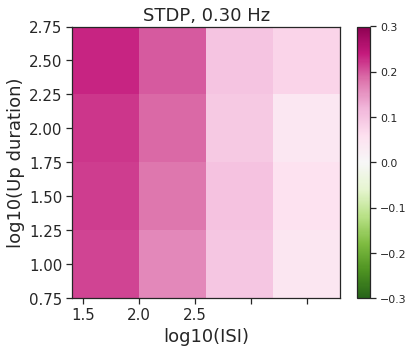

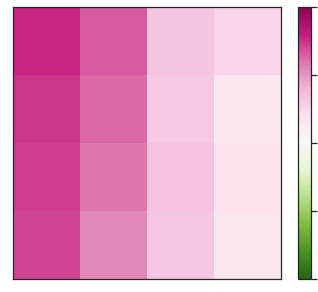

ISIM1.0_durM2.1
ISIM1.0_durM2.1_396_0.05
0.15595550000000002
ISIM1.0_durM2.4
ISIM1.0_durM2.4_487_0.05
0.15511449999999993
ISIM1.0_durM2.7
ISIM1.0_durM2.7_960_0.05
0.164601
ISIM1.0_durM3.0
ISIM1.0_durM3.0_855_0.05
0.14981199999999995
ISIM1.5_durM2.1
ISIM1.5_durM2.1_132_0.05
0.11392150000000001
ISIM1.5_durM2.4
ISIM1.5_durM2.4_181_0.05
0.11521400000000004
ISIM1.5_durM2.7
ISIM1.5_durM2.7_45_0.05
0.11448599999999998
ISIM1.5_durM3.0
ISIM1.5_durM3.0_616_0.05
0.10445899999999997
ISIM2.0_durM2.1
ISIM2.0_durM2.1_296_0.05
0.031266499999999975
ISIM2.0_durM2.4
ISIM2.0_durM2.4_446_0.05
0.018085499999999977
ISIM2.0_durM2.7
ISIM2.0_durM2.7_407_0.05
0.015288499999999927
ISIM2.0_durM3.0
ISIM2.0_durM3.0_741_0.05
0.025548999999999933
ISIM2.5_durM2.1
ISIM2.5_durM2.1_949_0.05
-0.019081499999999973
ISIM2.5_durM2.4
ISIM2.5_durM2.4_654_0.05
-0.01603500000000002
ISIM2.5_durM2.7
ISIM2.5_durM2.7_142_0.05
-0.02600150000000001
ISIM2.5_durM3.0
ISIM2.5_durM3.0_687_0.05
-0.0164995


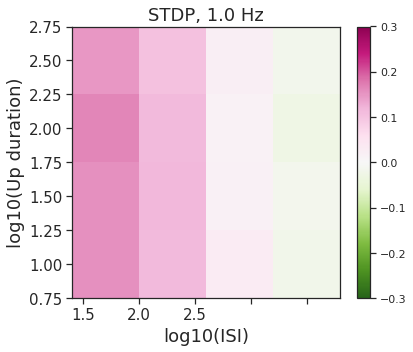

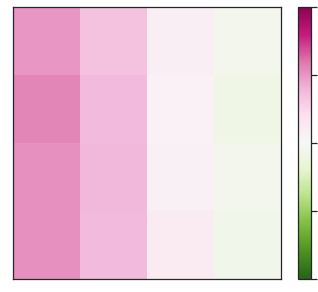

ISIM1.0_durM2.1
ISIM1.0_durM2.1_396_0.05
0.12457299999999993
ISIM1.0_durM2.4
ISIM1.0_durM2.4_487_0.05
0.12661599999999995
ISIM1.0_durM2.7
ISIM1.0_durM2.7_960_0.05
0.12415799999999999
ISIM1.0_durM3.0
ISIM1.0_durM3.0_855_0.05
0.126069
ISIM1.5_durM2.1
ISIM1.5_durM2.1_132_0.05
0.0818565
ISIM1.5_durM2.4
ISIM1.5_durM2.4_181_0.05
0.08649249999999997
ISIM1.5_durM2.7
ISIM1.5_durM2.7_45_0.05
0.08332499999999998
ISIM1.5_durM3.0
ISIM1.5_durM3.0_616_0.05
0.08136299999999996
ISIM2.0_durM2.1
ISIM2.0_durM2.1_296_0.05
-0.0035835000000000727
ISIM2.0_durM2.4
ISIM2.0_durM2.4_446_0.05
0.0005830000000000002
ISIM2.0_durM2.7
ISIM2.0_durM2.7_407_0.05
0.0024004999999999166
ISIM2.0_durM3.0
ISIM2.0_durM3.0_741_0.05
-0.012122499999999925
ISIM2.5_durM2.1
ISIM2.5_durM2.1_949_0.05
-0.053418999999999994
ISIM2.5_durM2.4
ISIM2.5_durM2.4_654_0.05
-0.03893449999999998
ISIM2.5_durM2.7
ISIM2.5_durM2.7_142_0.05
-0.04046749999999999
ISIM2.5_durM3.0
ISIM2.5_durM3.0_687_0.05
-0.035632


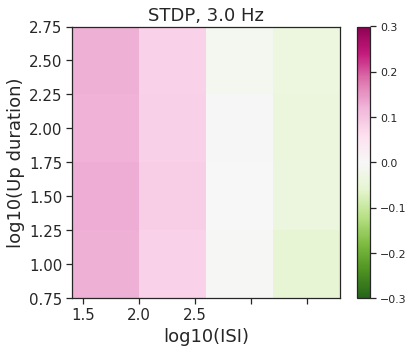

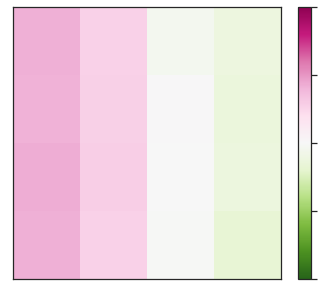

ISIM1.0_durM2.1
ISIM1.0_durM2.1_396_0.05
0.046772999999999954
ISIM1.0_durM2.4
ISIM1.0_durM2.4_487_0.05
0.04782200000000003
ISIM1.0_durM2.7
ISIM1.0_durM2.7_960_0.05
0.048600500000000046
ISIM1.0_durM3.0
ISIM1.0_durM3.0_855_0.05
0.0488575
ISIM1.5_durM2.1
ISIM1.5_durM2.1_132_0.05
0.003835000000000033
ISIM1.5_durM2.4
ISIM1.5_durM2.4_181_0.05
0.0015770000000000506
ISIM1.5_durM2.7
ISIM1.5_durM2.7_45_0.05
0.00445249999999997
ISIM1.5_durM3.0
ISIM1.5_durM3.0_616_0.05
0.0015530000000000266
ISIM2.0_durM2.1
ISIM2.0_durM2.1_296_0.05
0
ISIM2.0_durM2.4
ISIM2.0_durM2.4_446_0.05
0
ISIM2.0_durM2.7
ISIM2.0_durM2.7_407_0.05
0
ISIM2.0_durM3.0
ISIM2.0_durM3.0_741_0.05
0
ISIM2.5_durM2.1
ISIM2.5_durM2.1_949_0.05
0
ISIM2.5_durM2.4
ISIM2.5_durM2.4_654_0.05
0
ISIM2.5_durM2.7
ISIM2.5_durM2.7_142_0.05
0
ISIM2.5_durM3.0
ISIM2.5_durM3.0_687_0.05
0


Traceback (most recent call last):
  File "/tmp/ipykernel_2254423/1389764609.py", line 62, in <cell line: 39>
    syn_v_s= np.genfromtxt(f_s, delimiter=",", dtype=np.float64)
  File "/home/user/.local/lib/python3.8/site-packages/numpy/lib/npyio.py", line 1813, in genfromtxt
    fid = np.lib._datasource.open(fname, 'rt', encoding=encoding)
  File "/home/user/.local/lib/python3.8/site-packages/numpy/lib/_datasource.py", line 193, in open
    return ds.open(path, mode, encoding=encoding, newline=newline)
  File "/home/user/.local/lib/python3.8/site-packages/numpy/lib/_datasource.py", line 532, in open
    raise FileNotFoundError(f"{path} not found.")
FileNotFoundError: /mnt/SSD1/lr_params/synv_by2/ISIM2.0_durM2.1_296_0.05/a0.7t50/N_10/STDP_sleep10.0.csv not found.
Traceback (most recent call last):
  File "/tmp/ipykernel_2254423/1389764609.py", line 62, in <cell line: 39>
    syn_v_s= np.genfromtxt(f_s, delimiter=",", dtype=np.float64)
  File "/home/user/.local/lib/python3.8/site-packages

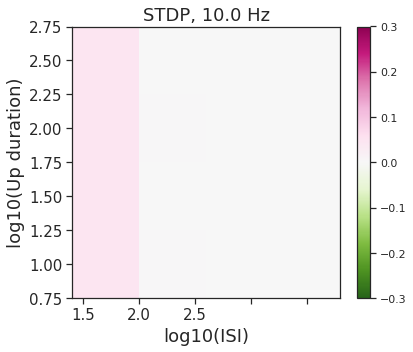

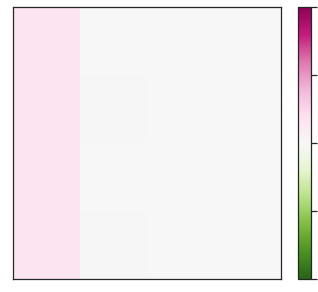

In [8]:
#comparing mean synaptic effi by learning rules and Hz by colormap  chaging DOWNM
nowdir = os.getcwd()+"/"
savedir = "../simple_model/"

syn_fol = "synv_by"
lr_p = "a0.7t50"
method = "median" #mean
norm =True
vmin = -0.30  
vmax = 0.30

sw = ["sleep", "wake"]
x_label=["1.0", "1.5","2.0", "2.5"]
y_label=["2.1", "2.4","2.7", "3.0"]
lr_li = ["STDP"]#["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
Hz_li = ["0.10", "0.30", "1.0", "3.0", "10.0"]

fs = 18
fs_l = 15

NE=10
dsb_w = "ISIM_40_0.05"
sleep_x = "ISIM"
sleep_y = "UPM"
x_li = [1.0, 1.5, 2.0, 2.25] #ISIM
y_li =[2.1, 2.4, 2.7, 3.0]  #UPM

x, y = np.meshgrid(np.array(x_li), np.array(y_li))
z = np.zeros((len(y_li),len(x_li)))

files = os.listdir(savedir + syn_fol +"/")

for lr in lr_li:
    for Hz in Hz_li:

        for m, ix in enumerate(x_li):
            for n,iy in enumerate(y_li):
                st = sleep_x+ str(ix) +"_" + sleep_y+ str(iy) 
                print(st)
                flag = 0
                for sp_f in files:
        #             print(sp_f)
                    if sp_f.find(st) !=-1:
                        print(sp_f)
                        dsb_s = sp_f
                        flag =1
                        break

                if flag ==0:
                    print("{} not found".format(st))

                else:
                    try:
                        fori_s = syn_fol+ "/"+dsb_s+"/"+lr_p+"/N_"+str(NE)
                        f_s = savedir + fori_s + "/"+lr+"_"+ "sleep"+Hz+".csv"
                        syn_v_s= np.genfromtxt(f_s, delimiter=",", dtype=np.float64)
        #                             s_m_li.append(np.mean(syn_v_s, axis=0)[1])
                        fori_w = syn_fol+ "/"+dsb_w+"/"+lr_p+"/N_"+str(NE)
                        f_w = savedir + fori_w + "/"+lr+"_"+ "wake"+Hz+".csv"
                        syn_v_w= np.genfromtxt(f_w, delimiter=",", dtype=np.float64)
        #                             w_m_li.append(np.mean(syn_v_w, axis=0)[1])
                        if method =="mean":
                            diff = np.mean(syn_v_s, axis=0)[1] - np.mean(syn_v_w, axis=0)[1]
                        elif method =="median":
                            diff = np.median(syn_v_s, axis=0)[1] - np.median(syn_v_w, axis=0)[1]
                    except:
                        traceback.print_exc()
                        diff = 0
                    z[m][n] = diff
                    print(diff)
            #                             ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap='hsv', linewidth=0.3)
            #                             plt.show()
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.set_title("{}, {} Hz".format(lr, Hz), fontsize = fs)
#         ax.set_xticks(x_li)
#         ax.set_yticks(y_li)
#         ax.tick_params("x", labelsize = fs_l)
#         ax.tick_params("y", labelsize = fs_l)
#         ax.set_xticklabels(x_label)
#         ax.set_xlabel("log10(ISI)", fontsize = fs)
#         ax.set_ylabel("log10(Up duration)", fontsize = fs)
        #                         plt.xlabel("log10(up duration)", fontsize = fs)
        if norm ==True:
            mappable=ax.pcolormesh(y,x,z, cmap="PiYG_r", norm=Normalize(vmin=vmin, vmax=vmax))
        else:
            mappable=ax.pcolormesh(y,x,z, cmap="PiYG_r")
        fig.colorbar(mappable, ax=ax)
        
        ax = plt.gca()
        ax.axes.xaxis.set_ticklabels([])
        ax.axes.yaxis.set_ticklabels([])

        plt.savefig("STDP_ISI_up_{}.SVG".format(Hz))

        plt.show()      
        

